## Hit calling

In [1]:
import pathlib

import pandas as pd

## Pathing

In [2]:
input_dir = pathlib.Path("inference_results")

output_file = input_dir / "hit_call_table.csv"

# Load summary
hit_summary_df = pd.read_csv(
    input_dir / "hit_summary.csv"
    ).rename(
    columns={
        "mean_score": "mean_logit_score",
    }
).set_index("Metadata_treatment")

print(hit_summary_df.shape)
hit_summary_df.head()

(551, 17)


,Pathway,mean_logit_score,median_score,score_std,n_scored_cells,n_score_plates,mean_cell_count,median_cell_count,mean_relative_cell_count,median_relative_cell_count,viability_std,n_treatment_wells,n_viability_plates,mean_average_precision,mean_normalized_average_precision,corrected_p_value,-log10(p-value)
Metadata_treatment,,,,,,,,,,,,,,,,,
UCD-0000253,Neuronal Signaling,0.594624,0.671355,0.363558,715.0,4.0,178.75,176.0,0.859845,0.825110,0.179958,4.0,4.0,1.0,1.0,0.002764,2.558445
UCD-0000872,Metabolism,0.999833,1.000000,0.000698,36.0,4.0,9.00,9.0,0.044441,0.041355,0.041632,4.0,4.0,1.0,1.0,0.002764,2.558445
UCD-0159319,Neuronal Signaling,0.837786,0.988373,0.249785,597.0,4.0,149.25,153.0,0.715468,0.747094,0.116341,4.0,4.0,1.0,1.0,0.002764,2.558445
UCD-0000730,Metabolism,0.984177,1.000000,0.113969,316.0,4.0,79.00,88.5,0.389627,0.412376,0.280501,4.0,4.0,1.0,1.0,0.002764,2.558445
UCD-0018569,Endocrinology & Hormones,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
treatment_well_file = input_dir / "treatment_well.csv"

treatment_well_df = pd.read_csv(treatment_well_file)

all_treatments = treatment_well_df['treatment'].unique()

print(f"Number of treatments screened: {len(all_treatments)}")

treatment_pathway_df = treatment_well_df.loc[
    :,["treatment", "Pathway"]
].copy().drop_duplicates().rename(columns={"treatment": "Metadata_treatment"}).set_index("Metadata_treatment")

Number of treatments screened: 551


In [4]:
for_hit_calling_df = (
    hit_summary_df
    .loc[:, ["Pathway", "mean_logit_score",	"mean_relative_cell_count",	"mean_average_precision", "corrected_p_value", "-log10(p-value)"]]
)

print(f"Number of treatments with profiles: {for_hit_calling_df.dropna().shape[0]}")
for_hit_calling_df.head()

Number of treatments with profiles: 450


,Pathway,mean_logit_score,mean_relative_cell_count,mean_average_precision,corrected_p_value,-log10(p-value)
Metadata_treatment,,,,,,
UCD-0000253,Neuronal Signaling,0.594624,0.859845,1.0,0.002764,2.558445
UCD-0000872,Metabolism,0.999833,0.044441,1.0,0.002764,2.558445
UCD-0159319,Neuronal Signaling,0.837786,0.715468,1.0,0.002764,2.558445
UCD-0000730,Metabolism,0.984177,0.389627,1.0,0.002764,2.558445
UCD-0018569,Endocrinology & Hormones,NaN,NaN,NaN,NaN,NaN


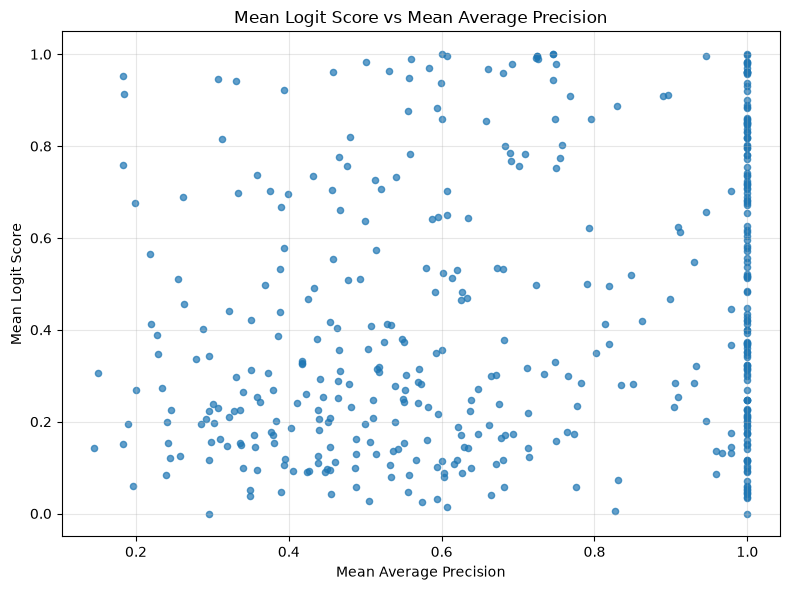

In [5]:
ax = for_hit_calling_df.plot.scatter(
    x="mean_average_precision",
    y="mean_logit_score",
    alpha=0.7,
    figsize=(8, 6)
)

ax.set_xlabel("Mean Average Precision")
ax.set_ylabel("Mean Logit Score")
ax.set_title("Mean Logit Score vs Mean Average Precision")
ax.grid(alpha=0.3)
ax.figure.tight_layout()

In [6]:
RELATIVE_COUNT_THRESHOLD = 0.8
LOGIT_THRESHOLD = 0.9
MAP_THRESHOLD = 0.05

hits_df = for_hit_calling_df.loc[
    (for_hit_calling_df["mean_relative_cell_count"] >= RELATIVE_COUNT_THRESHOLD)
    & (for_hit_calling_df["mean_logit_score"] >= LOGIT_THRESHOLD)
    & (for_hit_calling_df["corrected_p_value"] <= MAP_THRESHOLD)
].copy()
print(f"Number of hits identified: {hits_df.shape[0]}")
hits_df

Number of hits identified: 9


,Pathway,mean_logit_score,mean_relative_cell_count,mean_average_precision,corrected_p_value,-log10(p-value)
Metadata_treatment,,,,,,
UCD-0001921,Epigenetics,0.969737,0.818493,1.000000,0.002764,2.558445
UCD-0001812,Others,0.977959,0.811553,1.000000,0.002764,2.558445
UCD-0159268,Others,0.961089,0.996066,1.000000,0.002764,2.558445
UCD-0159406,Neuronal Signaling,0.908588,0.911870,0.889881,0.010298,1.987236
UCD-0000841,Neuronal Signaling,0.912086,0.944885,0.895833,0.010298,1.987236
UCD-0159442,Epigenetics,0.909725,1.018165,0.768353,0.025948,1.585898
UCD-0001419,Transmembrane Transporters,0.991753,0.896534,0.723653,0.041758,1.379258
UCD-0159486,Others,0.944601,0.904964,0.745833,0.040348,1.394181
UCD-0159487,Others,0.959437,0.816326,0.680556,0.048928,1.310439


In [7]:
for_hit_calling_df.head()

,Pathway,mean_logit_score,mean_relative_cell_count,mean_average_precision,corrected_p_value,-log10(p-value)
Metadata_treatment,,,,,,
UCD-0000253,Neuronal Signaling,0.594624,0.859845,1.0,0.002764,2.558445
UCD-0000872,Metabolism,0.999833,0.044441,1.0,0.002764,2.558445
UCD-0159319,Neuronal Signaling,0.837786,0.715468,1.0,0.002764,2.558445
UCD-0000730,Metabolism,0.984177,0.389627,1.0,0.002764,2.558445
UCD-0018569,Endocrinology & Hormones,NaN,NaN,NaN,NaN,NaN


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle, FancyArrowPatch
import seaborn as sns


def plot_pathway_screening_flow(
    treatment_pathway_df,
    for_hit_calling_df,
    hits_df,
    pathway_col="Pathway",
    stage_names=("All screened", "Profile obtained", "Final hits"),
    min_count=1,
    top_n=None,
    figsize=(10, 7),
    cmap="tab20",
    alpha=0.75,
    label_fontsize=10,
    title="Drug screening flow by pathway",
    process_labels=("Image acquisition", "Hit calling"),
):
    """
    Plot an alluvial/Sankey-like flow map showing pathway composition across:
    all screened compounds -> profile obtained/hit-calling set -> final hits.

    Parameters
    ----------
    treatment_pathway_df : pd.DataFrame
        Indexed by Metadata_treatment, contains pathway_col.
    for_hit_calling_df : pd.DataFrame
        Indexed by Metadata_treatment, contains pathway_col.
    hits_df : pd.DataFrame
        Indexed by Metadata_treatment, contains pathway_col.
    pathway_col : str
        Column containing pathway labels.
    stage_names : tuple[str]
        Names for the three stages.
    min_count : int
        Drop pathways whose total count across stages is below this.
    top_n : int or None
        If set, keep top_n pathways by total abundance and group the rest as "Other".
    process_labels : tuple[str, str]
        Labels for process arrows between stage 1->2 and 2->3.
    """

    def pathway_counts(df, stage):
        out = (
            df[[pathway_col]]
            .dropna()
            .assign(stage=stage)
            .groupby(["stage", pathway_col])
            .size()
            .rename("count")
            .reset_index()
        )
        return out

    def format_pathway_label(pathway):
        pathway = str(pathway)
        if " " in pathway:
            return pathway.replace(" ", "\n", 1)
        return pathway

    counts = pd.concat(
        [
            pathway_counts(treatment_pathway_df, stage_names[0]),
            pathway_counts(for_hit_calling_df, stage_names[1]),
            pathway_counts(hits_df, stage_names[2]),
        ],
        ignore_index=True,
    )

    total_by_pathway = counts.groupby(pathway_col)["count"].sum().sort_values(ascending=False)

    if top_n is not None and len(total_by_pathway) > top_n:
        keep = set(total_by_pathway.head(top_n).index)
        counts[pathway_col] = counts[pathway_col].where(
            counts[pathway_col].isin(keep),
            "Other"
        )
        counts = (
            counts.groupby(["stage", pathway_col], as_index=False)["count"]
            .sum()
        )

    total_by_pathway = counts.groupby(pathway_col)["count"].sum()
    keep_pathways = total_by_pathway[total_by_pathway >= min_count].index
    counts = counts[counts[pathway_col].isin(keep_pathways)].copy()

    pathways = (
        counts.groupby(pathway_col)["count"]
        .sum()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    full_index = pd.MultiIndex.from_product(
        [stage_names, pathways],
        names=["stage", pathway_col]
    )

    counts = (
        counts.set_index(["stage", pathway_col])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    stage_totals = counts.groupby("stage")["count"].transform("sum")
    counts["prop"] = counts["count"] / stage_totals.replace(0, np.nan)
    counts["prop"] = counts["prop"].fillna(0)

    gap = 0.01
    block_positions = {
        (stage, pathway): {
            "y0": 1.0,
            "y1": 1.0,
            "ymid": 1.0,
            "height": 0.0,
            "count": 0,
            "prop": 0.0,
        }
        for stage in stage_names
        for pathway in pathways
    }

    for stage in stage_names:
        y_top = 1.0
        stage_df = counts[counts["stage"] == stage].copy()
        stage_df_nonzero = stage_df[stage_df["count"] > 0].copy()
        n_pathways = len(stage_df_nonzero)
        total_gap = gap * max(n_pathways - 1, 0)
        usable_height = max(1.0 - total_gap, 0.0)

        for _, row in stage_df_nonzero.iterrows():
            pathway = row[pathway_col]
            h = row["prop"] * usable_height

            y1 = y_top
            y0 = y_top - h

            block_positions[(stage, pathway)] = {
                "y0": y0,
                "y1": y1,
                "ymid": (y0 + y1) / 2,
                "height": h,
                "count": row["count"],
                "prop": row["prop"],
            }

            y_top = y0 - gap

    palette = sns.color_palette(cmap, n_colors=max(len(pathways), 3))
    color_map = {p: palette[i % len(palette)] for i, p in enumerate(pathways)}

    fig, ax = plt.subplots(figsize=figsize)

    x_positions = {
        stage_names[0]: 0.0,
        stage_names[1]: 1.0,
        stage_names[2]: 2.0,
    }

    node_width = 0.08

    def draw_ribbon(x0, y0_low, y0_high, x1, y1_low, y1_high, color):
        dx = x1 - x0
        c0 = x0 + dx * 0.45
        c1 = x1 - dx * 0.45

        verts = [
            (x0, y0_high),
            (c0, y0_high),
            (c1, y1_high),
            (x1, y1_high),
            (x1, y1_low),
            (c1, y1_low),
            (c0, y0_low),
            (x0, y0_low),
            (x0, y0_high),
        ]

        codes = [
            Path.MOVETO,
            Path.CURVE4,
            Path.CURVE4,
            Path.CURVE4,
            Path.LINETO,
            Path.CURVE4,
            Path.CURVE4,
            Path.CURVE4,
            Path.CLOSEPOLY,
        ]

        patch = PathPatch(
            Path(verts, codes),
            facecolor=color,
            edgecolor="none",
            alpha=alpha,
        )
        ax.add_patch(patch)

    for pathway in pathways:
        color = color_map[pathway]

        for s0, s1 in zip(stage_names[:-1], stage_names[1:]):
            p0 = block_positions[(s0, pathway)]
            p1 = block_positions[(s1, pathway)]

            if p0["height"] <= 0 or p1["height"] <= 0:
                continue

            x0 = x_positions[s0] + node_width / 2
            x1 = x_positions[s1] - node_width / 2

            draw_ribbon(
                x0,
                p0["y0"],
                p0["y1"],
                x1,
                p1["y0"],
                p1["y1"],
                color,
            )

    for stage in stage_names:
        x = x_positions[stage]
        stage_total = counts.loc[counts["stage"] == stage, "count"].sum()

        for pathway in pathways:
            p = block_positions[(stage, pathway)]
            if p["height"] <= 0:
                continue

            rect = Rectangle(
                (x - node_width / 2, p["y0"]),
                node_width,
                p["height"],
                facecolor=color_map[pathway],
                edgecolor="white",
                linewidth=0.5,
                alpha=0.95,
            )
            ax.add_patch(rect)

            label_threshold = 0.0 if stage == stage_names[0] else 0.035
            if p["height"] > label_threshold:
                pathway_text = format_pathway_label(pathway)

                if stage == stage_names[0] and p["prop"] < 0.045:
                    label = pathway_text
                    fontsize = max(label_fontsize - 1, 8)
                else:
                    label = f"{pathway_text}\n{int(p['count'])} ({p['prop']:.1%})"
                    fontsize = label_fontsize

                x_text = x - 0.14

                ax.text(
                    x_text,
                    p["ymid"],
                    label,
                    va="center",
                    ha="right",
                    fontsize=fontsize,
                    clip_on=False,
                )

        ax.text(
            x,
            1.035,
            f"{stage}\nN={int(stage_total)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    process_y = 1.01
    process_text_y = 1.06
    stage_pairs = list(zip(stage_names[:-1], stage_names[1:]))

    for i, (s0, s1) in enumerate(stage_pairs):
        x_start = x_positions[s0] + node_width / 2
        x_end = x_positions[s1] - node_width / 2
        process_arrow = FancyArrowPatch(
            (x_start, process_y),
            (x_end, process_y),
            arrowstyle="<->",
            mutation_scale=12,
            linewidth=1.4,
            linestyle="--",
            color="dimgray",
        )
        ax.add_patch(process_arrow)

        if i < len(process_labels):
            ax.text(
                (x_start + x_end) / 2,
                process_text_y,
                process_labels[i],
                ha="center",
                va="bottom",
                fontsize=10,
                color="dimgray",
                fontweight="bold",
            )

    ax.set_xlim(-0.2, 2.12)
    ax.set_ylim(-0.01, 1.095)
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=6)

    fig.subplots_adjust(left=0.03, right=0.99, bottom=0.015, top=0.965)
    return fig, ax, counts

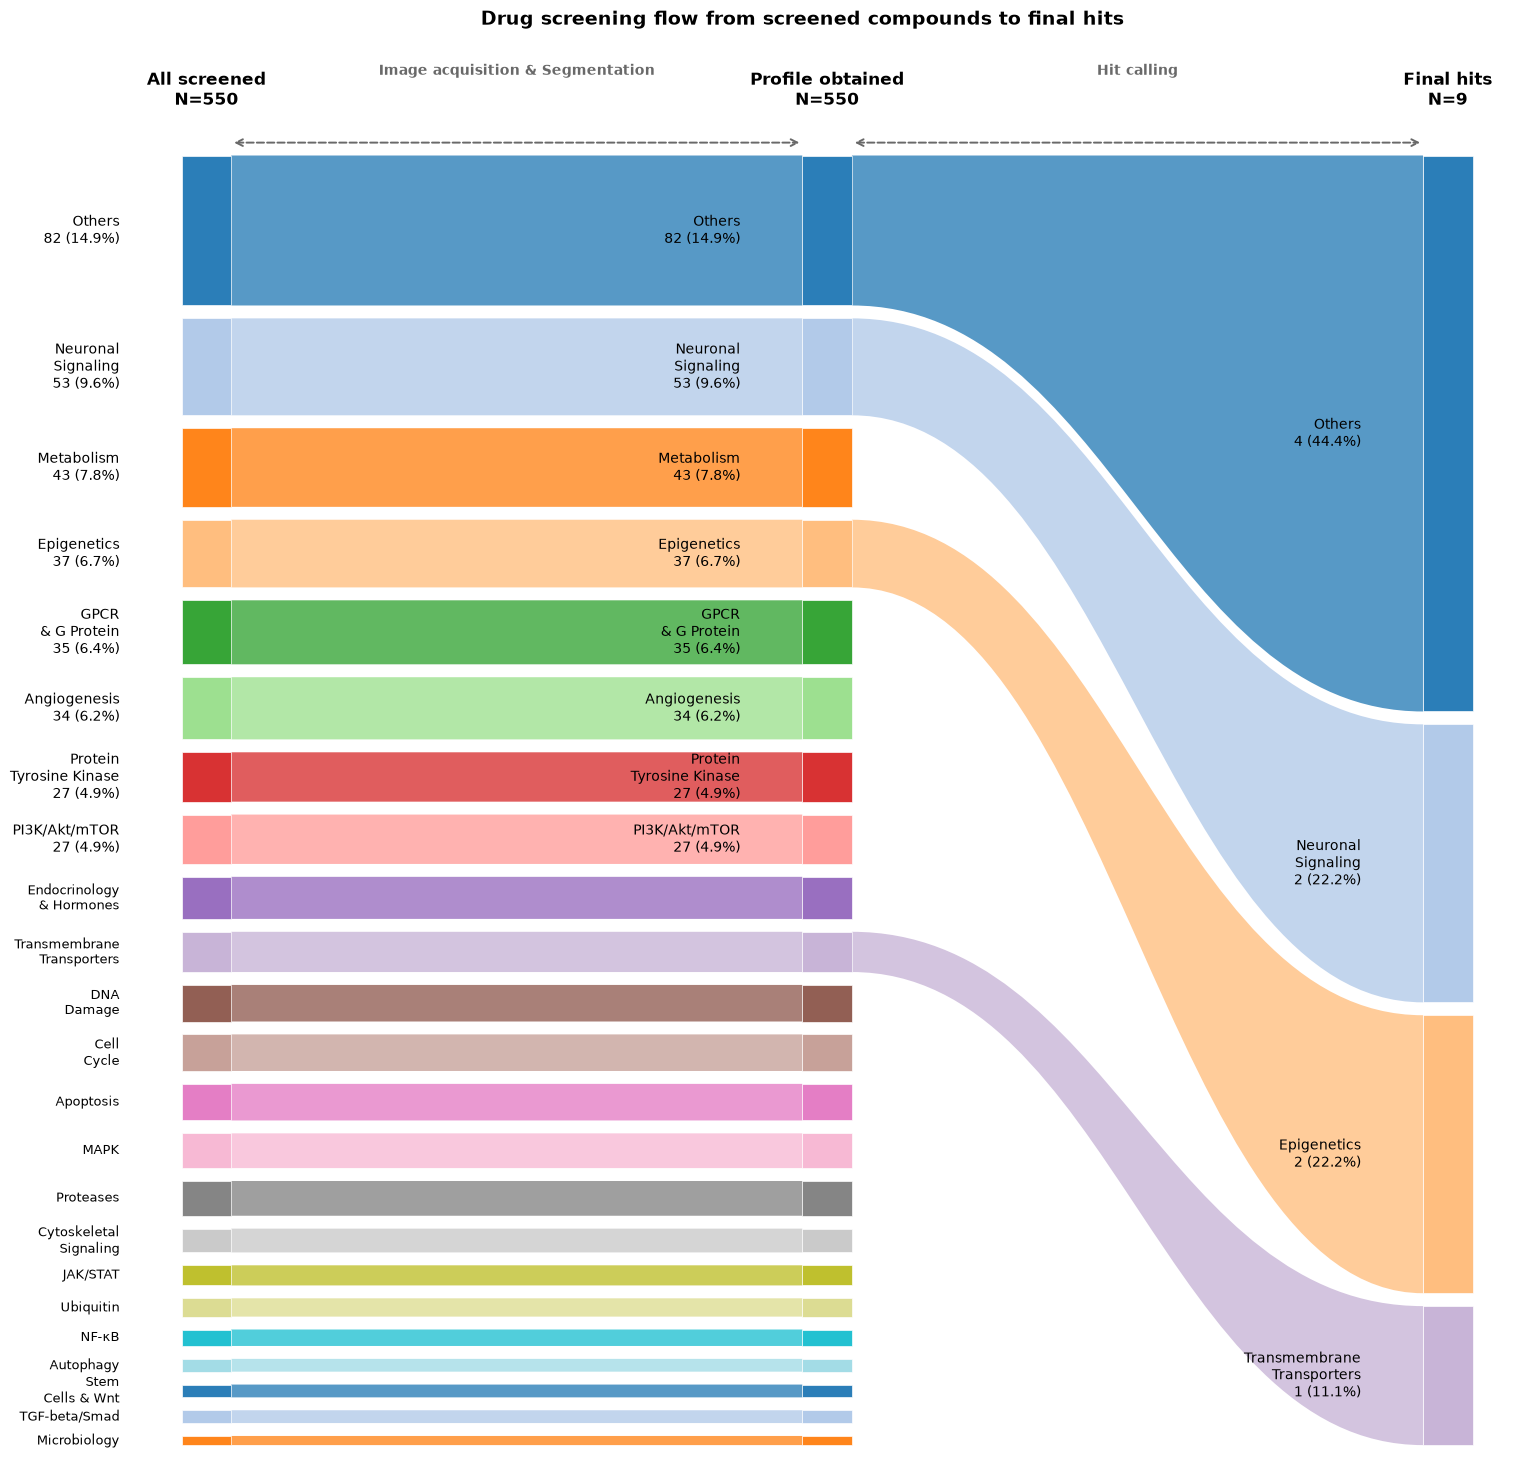

In [9]:
fig, ax, flow_counts = plot_pathway_screening_flow(
    treatment_pathway_df=treatment_pathway_df,
    for_hit_calling_df=for_hit_calling_df,
    hits_df=hits_df,
    pathway_col="Pathway",
    top_n=50,
    min_count=1,
    figsize=(15, 15),
    process_labels=("Image acquisition & Segmentation", "Hit calling"),
    title="Drug screening flow from screened compounds to final hits"
)

plt.show()

In [10]:
for_hit_calling_df['hit'] = False
for_hit_calling_df.loc[hits_df.index, 'hit'] = True

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_treatment_hit_scatter(
    df,
    x_col="mean_average_precision",
    y_col="mean_logit_score",
    size_col="mean_relative_cell_count",
    hit_col="hit",
    color_col="Pathway",
    label_col=None,
    ap_threshold=0.6,
    logit_threshold=0.9,
    figsize=(9, 6),
    size_min=30,
    size_max=450,
    log_size=True,
    color_by=True,
    cmap="tab20",
    save_path=None,
):
    """
    Scatter plot for treatment-level hit prioritization.

    x-axis: mean average precision
    y-axis: mean logit score
    dot size: log-scaled mean relative cell count
    marker/highlight: hit status
    optional color: categorical/continuous column, default Pathway

    Target region:
        mean_average_precision <= ap_threshold
        mean_logit_score >= logit_threshold
    """

    plot_df = df.copy()

    # Preserve treatment name from index
    if plot_df.index.name is not None:
        plot_df = plot_df.reset_index()
        treatment_col = df.index.name
    else:
        plot_df = plot_df.reset_index(names="Metadata_treatment")
        treatment_col = "Metadata_treatment"

    if label_col is None:
        label_col = treatment_col

    required_cols = [x_col, y_col, size_col, hit_col]
    if color_by and color_col is not None and color_col in plot_df.columns:
        required_cols.append(color_col)

    plot_df = plot_df.dropna(subset=required_cols).copy()
    plot_df[hit_col] = plot_df[hit_col].astype(bool)

    # ------------------------------------------------------------------
    # Log-scale dot size using the full observed range
    # ------------------------------------------------------------------
    raw_size = plot_df[size_col].astype(float)

    positive_min = raw_size[raw_size > 0].min()
    positive_max = raw_size[raw_size > 0].max()

    if pd.isna(positive_min):
        raise ValueError(
            f"`{size_col}` must contain at least one positive value for log-scaled sizing."
        )

    # Clip zeros/negatives to smallest positive value only for visualization
    safe_size = raw_size.clip(lower=positive_min)

    # Use log1p after rescaling by min to make very small values more separable
    # 0.004 -> log1p(1), max -> log1p(max / min)
    if log_size:
        size_transformed = np.log1p(safe_size / positive_min)
    else:
        size_transformed = safe_size

    if size_transformed.max() > size_transformed.min():
        plot_df["_point_size"] = (
            size_min
            + (size_transformed - size_transformed.min())
            / (size_transformed.max() - size_transformed.min())
            * (size_max - size_min)
        )
    else:
        plot_df["_point_size"] = (size_min + size_max) / 2

    # ------------------------------------------------------------------
    # Color handling
    # ------------------------------------------------------------------
    use_color = color_by and color_col is not None and color_col in plot_df.columns

    if use_color:
        if pd.api.types.is_numeric_dtype(plot_df[color_col]):
            color_is_numeric = True
            color_values = plot_df[color_col]
        else:
            color_is_numeric = False
            categories = sorted(plot_df[color_col].dropna().unique())
            palette = plt.get_cmap(cmap, len(categories))
            color_map = {
                cat: palette(i)
                for i, cat in enumerate(categories)
            }
            color_values = plot_df[color_col].map(color_map)
    else:
        color_is_numeric = False
        color_values = "gray"

    plot_df["_color"] = list(color_values) if use_color else "gray"

    nonhit_df = plot_df[~plot_df[hit_col]]
    hit_df = plot_df[plot_df[hit_col]]

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------------
    # Non-hit points: subtle
    # ------------------------------------------------------------------
    if use_color and color_is_numeric:
        nonhit_scatter = ax.scatter(
            nonhit_df[x_col],
            nonhit_df[y_col],
            s=nonhit_df["_point_size"],
            c=nonhit_df[color_col],
            cmap=cmap,
            marker="o",
            alpha=0.25,
            edgecolor="none",
            label="Not hit",
        )
    else:
        nonhit_scatter = ax.scatter(
            nonhit_df[x_col],
            nonhit_df[y_col],
            s=nonhit_df["_point_size"],
            c=nonhit_df["_color"],
            marker="o",
            alpha=0.25,
            edgecolor="none",
            label="Not hit",
        )

    # ------------------------------------------------------------------
    # Hit points: obvious highlighted marker
    # ------------------------------------------------------------------
    if use_color and color_is_numeric:
        hit_scatter = ax.scatter(
            hit_df[x_col],
            hit_df[y_col],
            s=hit_df["_point_size"] * 1.5,
            c=hit_df[color_col],
            cmap=cmap,
            marker="*",
            alpha=0.98,
            edgecolor="black",
            linewidth=1.0,
            label="Hit",
        )
    else:
        hit_scatter = ax.scatter(
            hit_df[x_col],
            hit_df[y_col],
            s=hit_df["_point_size"] * 1.5,
            c=hit_df["_color"],
            marker="*",
            alpha=0.98,
            edgecolor="black",
            linewidth=1.0,
            label="Hit",
        )

    # ------------------------------------------------------------------
    # Threshold lines
    # ------------------------------------------------------------------
    ax.axvline(
        ap_threshold,
        linestyle="--",
        linewidth=1.2,
        color="black",
        alpha=0.7,
    )
    ax.axhline(
        logit_threshold,
        linestyle="--",
        linewidth=1.2,
        color="black",
        alpha=0.7,
    )

    # Shade target region: AP <= threshold and logit >= threshold
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    if y_max > y_min:
        ax.axvspan(
            x_min,
            ap_threshold,
            ymin=(logit_threshold + y_min) / (y_max + y_min),
            ymax=1,
            alpha=0.08,
            color="gray",
        )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.text(
        ap_threshold,
        logit_threshold,
        f"  AP ≤ {ap_threshold}\n  logit ≥ {logit_threshold}",
        ha="left",
        va="bottom",
        fontsize=9,
    )

    ax.set_xlabel("Mean Average Precision")
    ax.set_ylabel("Mean Logit Score")
    ax.set_title("Treatment-Level Hit Prioritization")

    ax.grid(alpha=0.2)

    # ------------------------------------------------------------------
    # Hit-status legend
    # ------------------------------------------------------------------
    marker_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            label="Not hit",
            markerfacecolor="gray",
            markersize=8,
            alpha=0.35,
        ),
        Line2D(
            [0], [0],
            marker="*",
            color="black",
            label="Hit",
            markerfacecolor="gray",
            markersize=14,
        ),
    ]

    marker_legend = ax.legend(
        handles=marker_handles,
        title="Hit status",
        loc="upper right",
        frameon=True,
    )
    ax.add_artist(marker_legend)

    # ------------------------------------------------------------------
    # Size legend: span full observed range, not just quartiles
    # ------------------------------------------------------------------
    size_legend_values = np.array([
        positive_min,
        0.01,
        0.05,
        0.1,
        0.5,
        1.0,
        positive_max,
    ])

    # Keep only values inside observed range, then ensure min/max are included
    size_legend_values = size_legend_values[
        (size_legend_values >= positive_min) & 
        (size_legend_values <= positive_max)
    ]

    size_legend_values = np.unique(
        np.concatenate([[positive_min], size_legend_values, [positive_max]])
    )

    size_handles = []

    for val in size_legend_values:
        safe_val = max(val, positive_min)
        transformed_val = np.log1p(safe_val / positive_min)

        if size_transformed.max() > size_transformed.min():
            point_size = (
                size_min
                + (transformed_val - size_transformed.min())
                / (size_transformed.max() - size_transformed.min())
                * (size_max - size_min)
            )
        else:
            point_size = (size_min + size_max) / 2

        size_handles.append(
            plt.scatter(
                [],
                [],
                s=point_size,
                color="gray",
                alpha=0.35,
                edgecolor="none",
                label=f"{val:.3g}",
            )
        )

    size_legend = ax.legend(
        handles=size_handles,
        title=f"{size_col}" if not log_size else f"{size_col}\n (log scale)",
        loc="lower right",
        frameon=True,
    )
    ax.add_artist(size_legend)

    # ------------------------------------------------------------------
    # Color legend / colorbar
    # ------------------------------------------------------------------
    if use_color:
        if color_is_numeric:
            cbar = fig.colorbar(nonhit_scatter, ax=ax, pad=0.02)
            cbar.set_label(color_col)
        else:
            color_handles = [
                Line2D(
                    [0], [0],
                    marker="o",
                    color="none",
                    label=str(cat),
                    markerfacecolor=color_map[cat],
                    markeredgecolor="none",
                    markersize=8,
                    alpha=0.8,
                )
                for cat in categories
            ]

            ax.legend(
                handles=color_handles,
                title=color_col,
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                frameon=True,
            )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

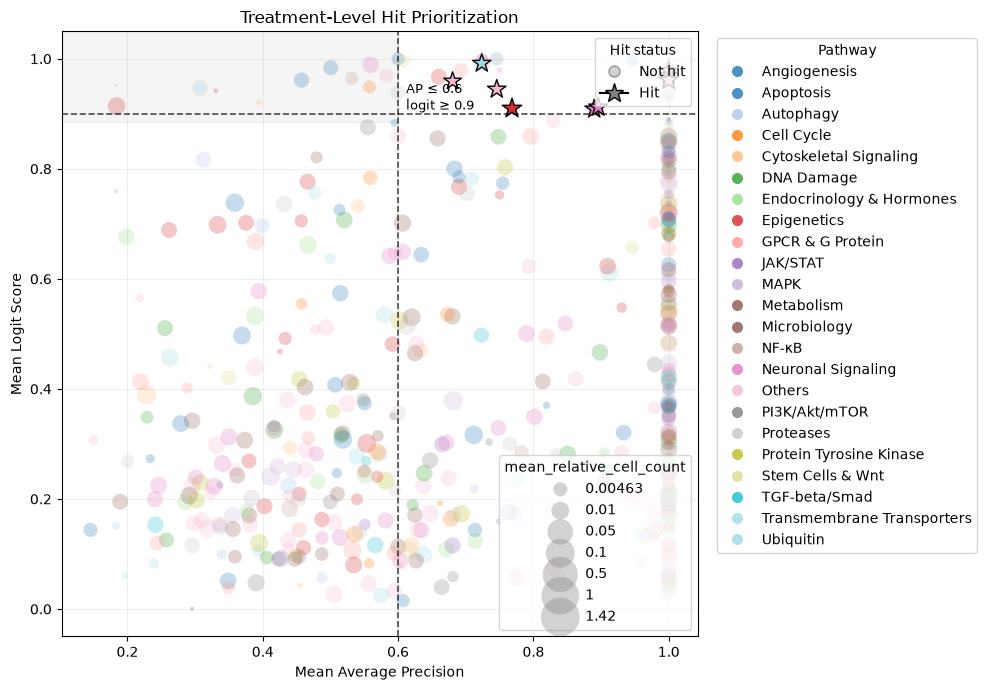

In [12]:
fig, ax = plot_treatment_hit_scatter(
    for_hit_calling_df,
    color_col="Pathway",
    figsize=(10, 7),
    ap_threshold=0.6,
    logit_threshold=0.9,
    size_min=10,
    size_max=200,
    log_size=False
)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def plot_hit_threshold_metric_panels(
    df,
    x_col="mean_average_precision",
    y_col="mean_logit_score",
    count_col="mean_relative_cell_count",
    pathway_col="Pathway",
    hit_col="hit",
    ap_threshold=0.6,
    logit_threshold=0.9,
    relative_count_threshold=0.8,
    figsize=(13, 5.5),
    cmap_pathway="tab20",
    point_size=45,
    hit_size=120,
    alpha_nonhit=0.45,
    alpha_hit=0.95,
    save_path=None,
):
    """
    Two-panel hit-threshold visualization.

    Left:
        MAP vs logit, colored by pathway.

    Right:
        MAP vs logit, colored by relative cell count.

    In both panels:
        - x-axis = mean average precision
        - y-axis = mean logit score
        - non-hits = circles
        - hits = stars with black outline
        - threshold region = AP <= ap_threshold and logit >= logit_threshold
        - relative cell count threshold = relative_count_threshold
    """

    plot_df = df.copy()

    # Preserve treatment name from index
    if plot_df.index.name is not None:
        plot_df = plot_df.reset_index()
        treatment_col = df.index.name
    else:
        plot_df = plot_df.reset_index(names="Metadata_treatment")
        treatment_col = "Metadata_treatment"

    required_cols = [
        x_col,
        y_col,
        count_col,
        pathway_col,
        hit_col,
    ]

    plot_df = plot_df.dropna(subset=required_cols).copy()
    plot_df[hit_col] = plot_df[hit_col].astype(bool)

    nonhit_df = plot_df.loc[~plot_df[hit_col]].copy()
    hit_df = plot_df.loc[plot_df[hit_col]].copy()

    # Shared limits with a little padding
    x_min = plot_df[x_col].min()
    x_max = plot_df[x_col].max()
    y_min = plot_df[y_col].min()
    y_max = plot_df[y_col].max()

    x_pad = 0.04 * (x_max - x_min) if x_max > x_min else 0.05
    y_pad = 0.04 * (y_max - y_min) if y_max > y_min else 0.05

    x_lim = (x_min - x_pad, x_max + x_pad)
    y_lim = (y_min - y_pad, y_max + y_pad)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    ax_pathway, ax_count = axes

    # ------------------------------------------------------------------
    # Helper: thresholds and target-region shading
    # ------------------------------------------------------------------
    def add_threshold_guides(ax):
        ax.axvline(
            ap_threshold,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.75,
        )
        ax.axhline(
            logit_threshold,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.75,
        )

        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)

        # Shade AP <= threshold and logit >= threshold
        ymin, ymax = ax.get_ylim()
        if ymax > ymin:
            ax.axvspan(
                x_lim[0],
                ap_threshold,
                ymin=(logit_threshold - ymin) / (ymax - ymin),
                ymax=1,
                color="gray",
                alpha=0.10,
                zorder=0,
            )

        ax.text(
            ap_threshold,
            logit_threshold,
            f"  MAP ≤ {ap_threshold}\n  logit ≥ {logit_threshold}",
            ha="left",
            va="bottom",
            fontsize=9,
        )

        ax.grid(alpha=0.25)
        ax.set_xlabel("Mean Average Precision")

    # ------------------------------------------------------------------
    # Panel 1: color by pathway
    # ------------------------------------------------------------------
    pathways = sorted(plot_df[pathway_col].dropna().unique())
    pathway_palette = sns.color_palette(cmap_pathway, n_colors=len(pathways))
    pathway_color_map = {
        pathway: pathway_palette[i]
        for i, pathway in enumerate(pathways)
    }

    nonhit_colors = nonhit_df[pathway_col].map(pathway_color_map)
    hit_colors = hit_df[pathway_col].map(pathway_color_map)

    ax_pathway.scatter(
        nonhit_df[x_col],
        nonhit_df[y_col],
        c=nonhit_colors,
        s=point_size,
        marker="o",
        alpha=alpha_nonhit,
        edgecolor="black",
        label="Not hit",
    )

    ax_pathway.scatter(
        hit_df[x_col],
        hit_df[y_col],
        c=hit_colors,
        s=hit_size,
        marker="*",
        alpha=alpha_hit,
        edgecolor="black",
        linewidth=0.8,
        label="Hit",
    )

    add_threshold_guides(ax_pathway)

    ax_pathway.set_title("Colored by pathway")
    ax_pathway.set_ylabel("Mean Logit Score")

    # Pathway legend
    pathway_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            label=str(pathway),
            markerfacecolor=pathway_color_map[pathway],
            markeredgecolor="none",
            markersize=7,
            alpha=0.85,
        )
        for pathway in pathways
    ]

    pathway_legend = ax_pathway.legend(
        handles=pathway_handles,
        title=pathway_col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        fontsize=8,
        title_fontsize=9,
    )

    # ------------------------------------------------------------------
    # Panel 2: color by relative cell count
    # ------------------------------------------------------------------

    # Example interpretation:
    # low relative count  -> red
    # threshold           -> white
    # high relative count -> blue
    relative_count_threshold = 0.8  # change this as needed

    count_vmin = plot_df[count_col].min()
    count_vmax = plot_df[count_col].max()

    count_cmap = LinearSegmentedColormap.from_list(
        "relative_count_red_white_blue",
        ["red", "white", "blue"]
    )

    count_norm = TwoSlopeNorm(
        vmin=count_vmin,
        vcenter=relative_count_threshold,
        vmax=count_vmax,
    )

    count_scatter_nonhit = ax_count.scatter(
        nonhit_df[x_col],
        nonhit_df[y_col],
        c=nonhit_df[count_col],
        cmap=count_cmap,
        norm=count_norm,
        s=point_size,
        marker="o",
        alpha=alpha_nonhit,
        edgecolor="black",
        label="Not hit",
    )

    ax_count.scatter(
        hit_df[x_col],
        hit_df[y_col],
        c=hit_df[count_col],
        cmap=count_cmap,
        norm=count_norm,
        s=hit_size,
        marker="*",
        alpha=alpha_hit,
        edgecolor="black",
        linewidth=0.8,
        label="Hit",
    )

    add_threshold_guides(ax_count)

    ax_count.set_title(
        f"Colored by relative cell count\nwhite centered at {relative_count_threshold:g}"
    )

    cbar = fig.colorbar(
        count_scatter_nonhit,
        ax=ax_count,
        pad=0.02,
    )

    cbar.set_label(count_col)

    # Optional: emphasize the threshold on the colorbar
    cbar.ax.axhline(
        relative_count_threshold,
        color="black",
        linewidth=1.2,
    )

    # ------------------------------------------------------------------
    # Shared hit-status legend
    # ------------------------------------------------------------------
    hit_status_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            label="Not hit",
            markerfacecolor="gray",
            markeredgecolor="none",
            markersize=7,
            alpha=alpha_nonhit,
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color="black",
            label="Hit",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=13,
            alpha=alpha_hit,
        ),
    ]

    ax_count.legend(
        handles=hit_status_handles,
        title="Hit status",
        loc="lower right",
        frameon=True,
    )

    fig.suptitle(
        "Treatment-Level Hit Thresholding",
        fontsize=14,
        fontweight="bold",
        y=1.03,
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes, plot_df

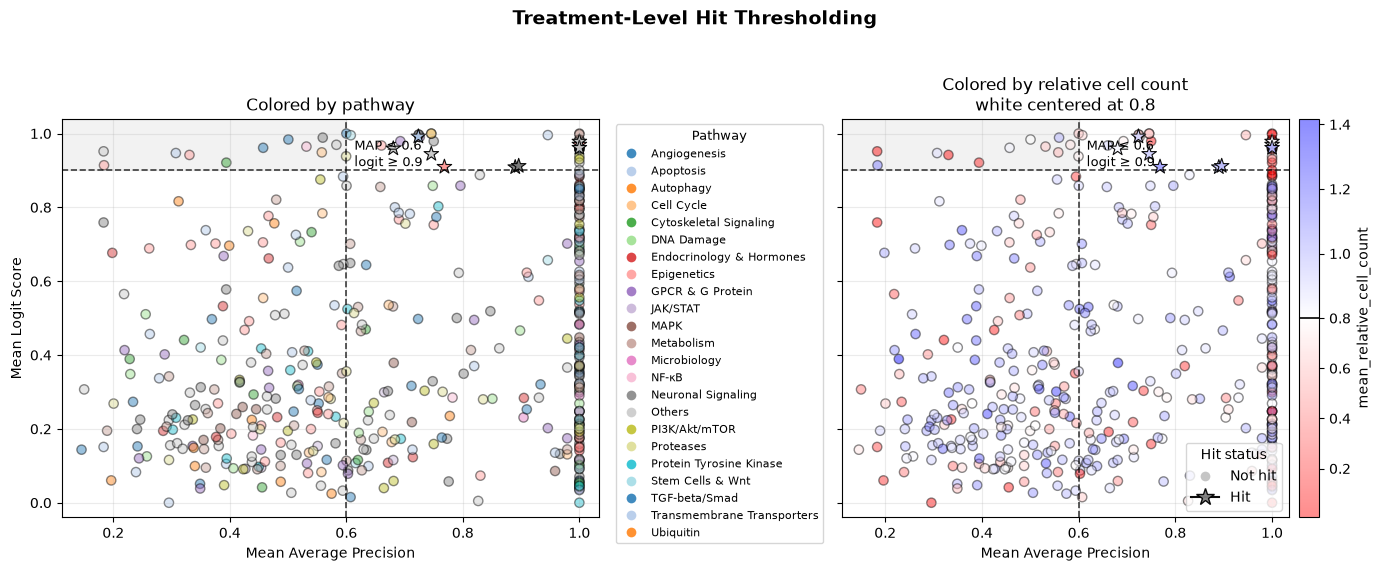

In [14]:
fig, axes, plot_df = plot_hit_threshold_metric_panels(
    for_hit_calling_df,
    x_col="mean_average_precision",
    y_col="mean_logit_score",
    count_col="mean_relative_cell_count",
    pathway_col="Pathway",
    hit_col="hit",
    ap_threshold=0.6,
    logit_threshold=0.9,
    relative_count_threshold=0.8,
    figsize=(14, 5.5),
    save_path="hit_threshold_metric_panels.png",
)

plt.show()

In [15]:
for_hit_calling_df.sort_values(by='hit', ascending=False).to_csv(output_file)